<a href="https://colab.research.google.com/github/jhlopesalves/data-science-notebooks/blob/main/Python/projects/fcc_magic_gamma/fcc_MAGIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Dataset:
Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

Donated by:
P. Savicky
Institute of Computer Science, AS of CR
Czech Republic
savicky '@' cs.cas.cz

In [2]:
cols = [
	"fLength",
	"fWidth",
	"fSize",
	"fConc",
	"fConc1",
	"fAsym",
	"fM3Long",
	"fM3Trans",
	"fAlpha",
	"fDist",
	"class",
]
url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/refs/heads/main/Python/projects/fcc_magic_gamma/data/magic04.data"
df = pd.read_csv(url, names=cols, usecols=lambda col: not col.startswith("Unnamed"))
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [3]:
# Binary encode: gamma ('g') → 1, hadron ('h') → 0, as int8
df["class"] = (df["class"].str.lower() == "g").astype("int8")

# Basic sanity check
class_counts = df["class"].value_counts().sort_index()
print({0: int(class_counts.get(0, 0)), 1: int(class_counts.get(1, 1))})


{0: 6688, 1: 12332}


In [4]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


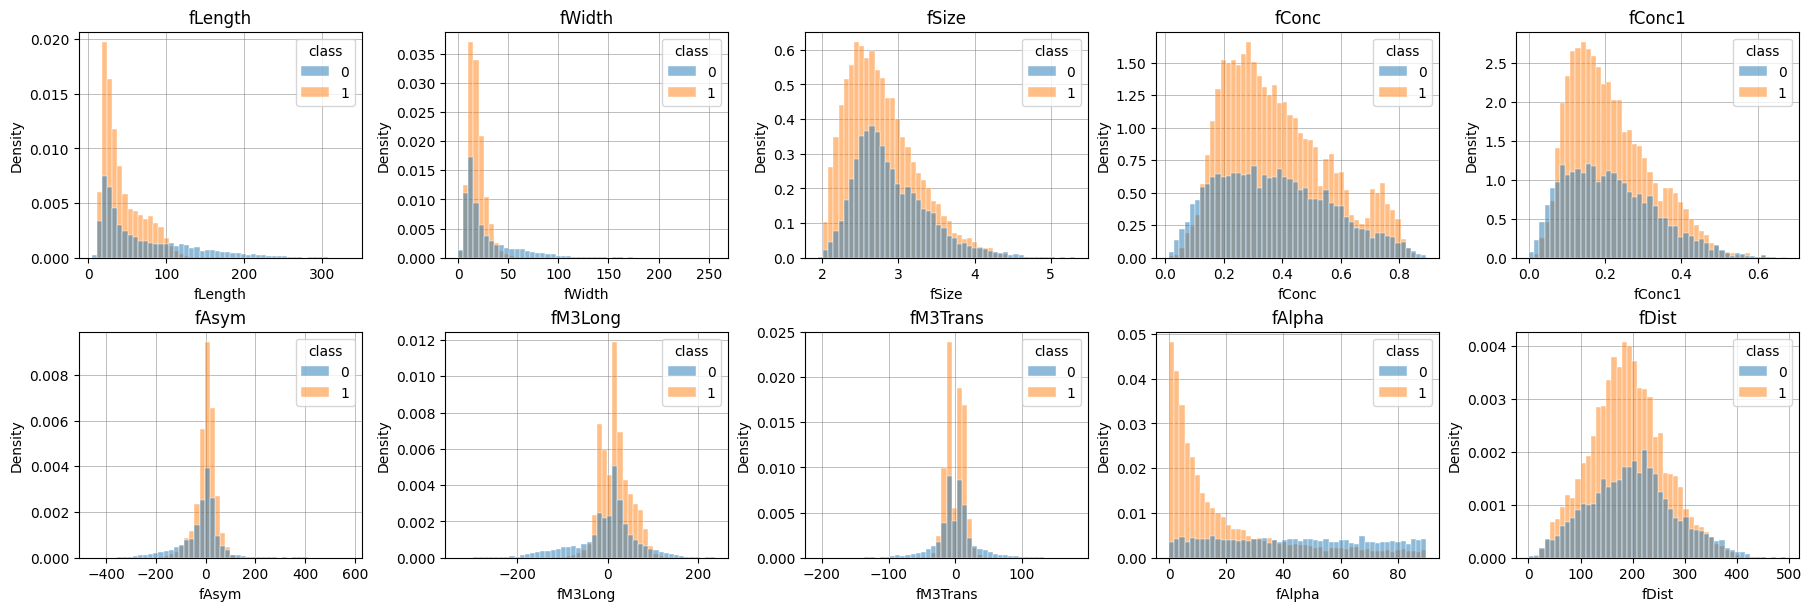

In [5]:
feature_names = cols[:-1]
num_features = len(feature_names)

# Grid size: 2 rows × 5 cols for 10 features
fig, axes = plt.subplots(2, 5, figsize=(18, 6), constrained_layout=True)
axes = axes.ravel()

for axis, feature in zip(axes, feature_names):
    sns.histplot(
        data=df,
        x=feature,
        hue="class",
        hue_order=[0, 1],
        stat="density",
        bins=50,
        alpha=0.5,
        edgecolor="white",
        linewidth=0.3,
        ax=axis,
    )
    axis.set_title(feature)
    axis.set_xlabel(feature)
    axis.set_ylabel("Density")
    axis.grid(True, alpha=0.6, linewidth=0.6, color="grey")
    axis.set_axisbelow(True)

# Single, consistent legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["hadron (0)", "gamma (1)"], loc="upper right", frameon=False)
plt.show()


# Train, validation, test datasets

In [6]:
from sklearn.model_selection import train_test_split

X = df[feature_names].copy()
y = df["class"].copy()

# First: pull out 20% test
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Second: from the remaining 80%, take 25% for validation -> 0.25 * 0.80 = 0.20 overall
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid, test_size=0.25, stratify=y_train_valid, random_state=42
)

In [7]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler

def fit_preprocessor(X_train_frame: pd.DataFrame) -> StandardScaler:
    """Fit a StandardScaler on the training features only."""
    scaler = StandardScaler()
    scaler.fit(X_train_frame.values.astype("float32"))
    return scaler

def transform_features(X_frame: pd.DataFrame, scaler: StandardScaler) -> np.ndarray:
    """Apply a fitted scaler to any split. Always return float32 for TF."""
    return scaler.transform(X_frame.values.astype("float32")).astype("float32")

def oversample_train(
    X_train_array: np.ndarray, y_train_array: np.ndarray, seed: int = 42
) -> tuple[np.ndarray, np.ndarray]:
    """Randomly oversample the minority class on the training set only."""
    ros = RandomOverSampler(random_state=42)
    X_res, y_res = ros.fit_resample(X_train_array, y_train_array)
    return X_res.astype("float32"), y_res.astype("int8")

## KNN

In [11]:
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

In [12]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [13]:
y_pred = knn_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.73      0.73      1331
           1       0.86      0.85      0.85      2473

    accuracy                           0.81      3804
   macro avg       0.79      0.79      0.79      3804
weighted avg       0.81      0.81      0.81      3804



## Naive Bayes

In [14]:
from sklearn.naive_bayes import GaussianNB

In [15]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

In [16]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.66      0.39      0.49      1331
           1       0.73      0.89      0.80      2473

    accuracy                           0.72      3804
   macro avg       0.69      0.64      0.65      3804
weighted avg       0.71      0.72      0.69      3804



## Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

In [19]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.71      0.69      1331
           1       0.84      0.81      0.83      2473

    accuracy                           0.78      3804
   macro avg       0.76      0.76      0.76      3804
weighted avg       0.78      0.78      0.78      3804



## Support-Vector Classification (SVC)

In [20]:
from sklearn.svm import SVC

In [21]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train)

In [22]:
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      1331
           1       0.88      0.89      0.89      2473

    accuracy                           0.85      3804
   macro avg       0.84      0.84      0.84      3804
weighted avg       0.85      0.85      0.85      3804



### Neural Networks

In [23]:
import tensorflow as tf

In [24]:
print("TensorFlow:", tf.__version__)
print("TF built with CUDA:", tf.test.is_built_with_cuda())

TensorFlow: 2.19.0
TF built with CUDA: True


In [25]:
# List and configure GPU(s)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs detected and memory growth set: {[g.name for g in gpus]}")
    except Exception as e:
        print("Could not set memory growth:", e)
else:
    print("No GPU detected. In Colab: Runtime → Change runtime type → Hardware accelerator → GPU.")

# Optional: enable XLA JIT for a small speed boost on many models
tf.config.optimizer.set_jit(True)

GPUs detected and memory growth set: ['/physical_device:GPU:0']


In [26]:
def plot_history(history):
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
	ax1.plot(history.history["loss"], label="loss")
	ax1.plot(history.history["val_loss"], label="val_loss")
	ax1.set_xlabel("Epoch")
	ax1.set_ylabel("Binary crossentropy")
	ax1.grid(True)

	ax2.plot(history.history["accuracy"], label="accuracy")
	ax2.plot(history.history["val_accuracy"], label="val_accuracy")
	ax2.set_xlabel("Epoch")
	ax2.set_ylabel("Accuracy")
	ax2.grid(True)

	plt.show()

In [27]:
def train_model(
	X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs
) -> tuple:
	nn_model = tf.keras.Sequential([
		tf.keras.layers.Input(shape=(10,)),
		tf.keras.layers.Dense(num_nodes, activation="relu"),
		tf.keras.layers.Dropout(dropout_prob),
		tf.keras.layers.Dense(num_nodes, activation="relu"),
		tf.keras.layers.Dropout(dropout_prob),
		tf.keras.layers.Dense(1, activation="sigmoid"),
	])

	nn_model.compile(
		optimizer=tf.keras.optimizers.Adam(lr),
		loss="binary_crossentropy",
		metrics=["accuracy"],
	)

	history = nn_model.fit(
		X_train,
		y_train,
		epochs=epochs,
		batch_size=batch_size,
		validation_split=0.2,
		verbose=0,
	)

	return nn_model, history

16 nodes, dropout 0, lr 0.01, batch size 16


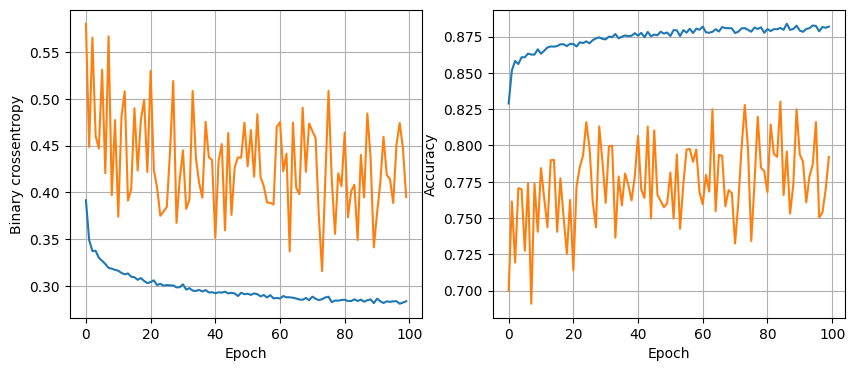

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8768 - loss: 0.3215
16 nodes, dropout 0, lr 0.01, batch size 32


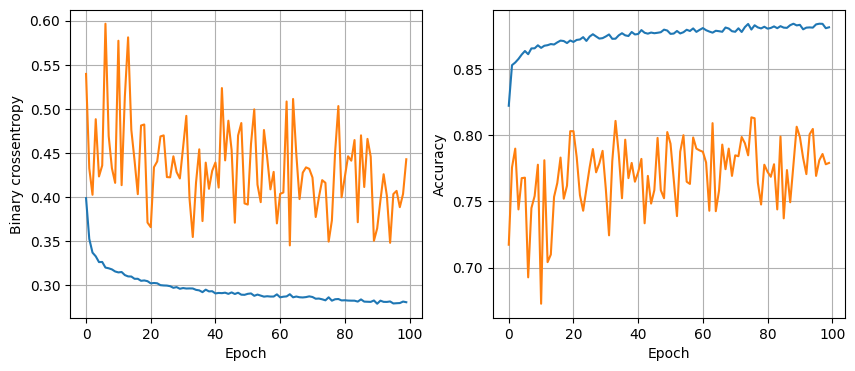

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8730 - loss: 0.3063
16 nodes, dropout 0, lr 0.01, batch size 64


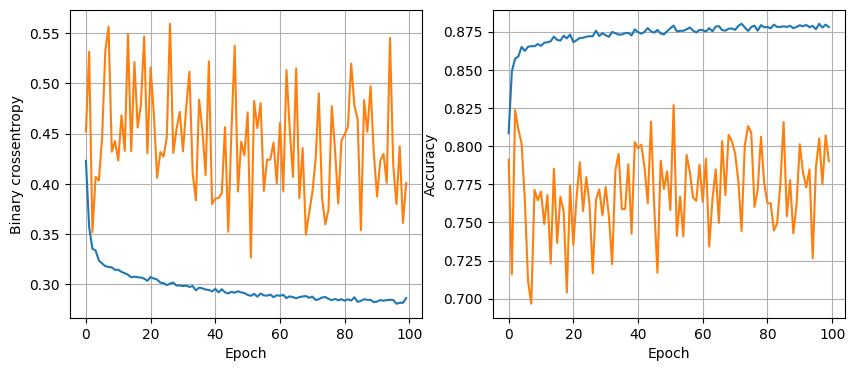

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8788 - loss: 0.3075
16 nodes, dropout 0, lr 0.01, batch size 128


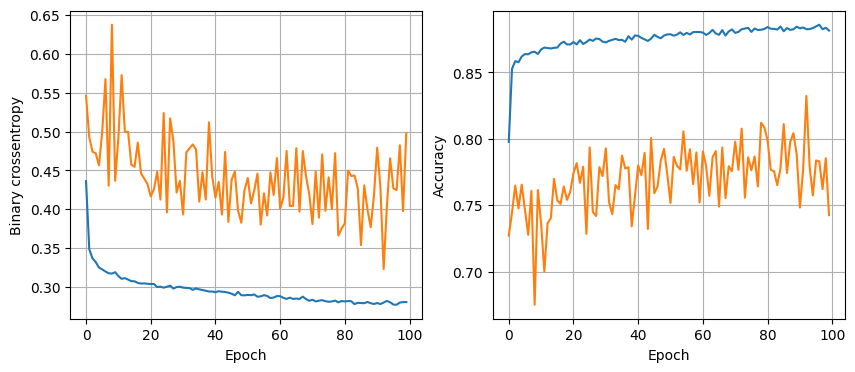

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8791 - loss: 0.3047
16 nodes, dropout 0, lr 0.005, batch size 16


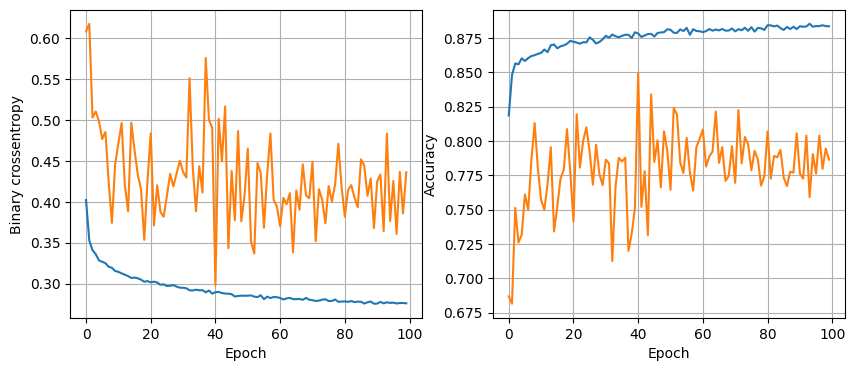

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8711 - loss: 0.3092
16 nodes, dropout 0, lr 0.005, batch size 32


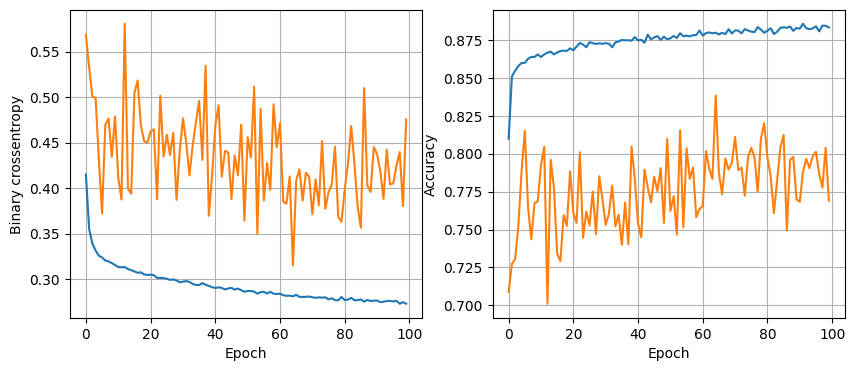

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8789 - loss: 0.3028
16 nodes, dropout 0, lr 0.005, batch size 64


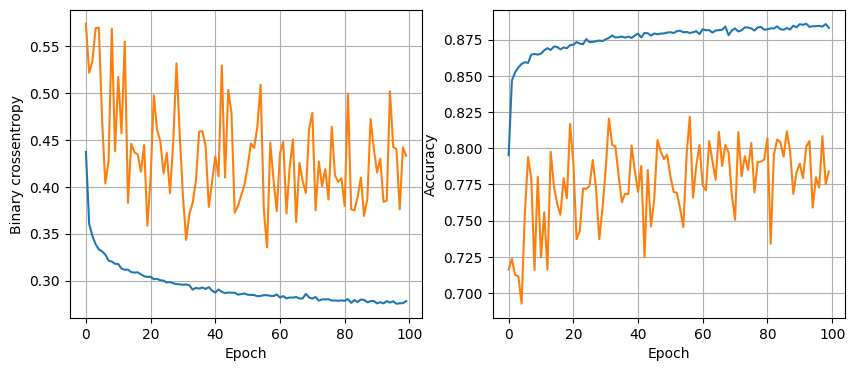

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8706 - loss: 0.3053
16 nodes, dropout 0, lr 0.005, batch size 128


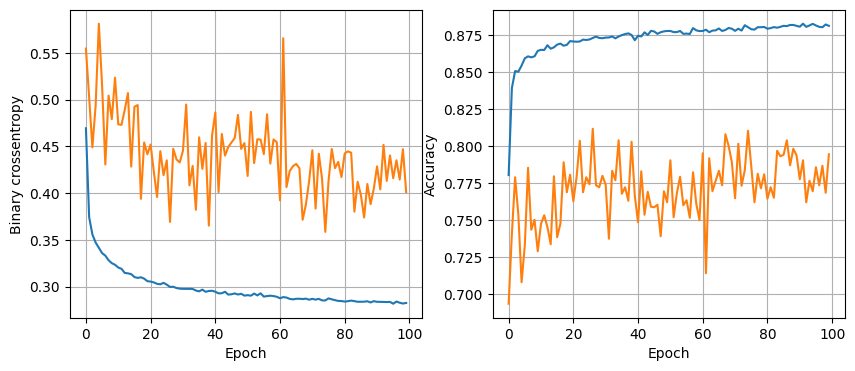

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8739 - loss: 0.3084
16 nodes, dropout 0, lr 0.001, batch size 16


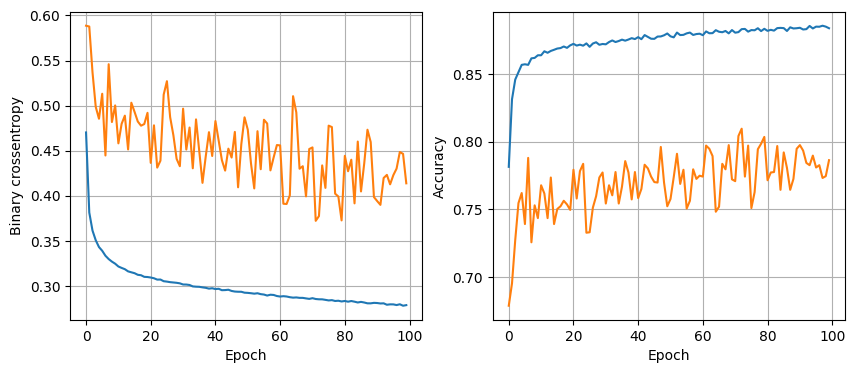

KeyboardInterrupt: 

In [30]:
least_val_loss = float("inf")
least_loss_model = None
epochs = 100
for num_nodes in [16, 32, 64]:
        for dropout_prob in [0, 0.2]:
                for lr in [0.01, 0.005, 0.001]:
                        for batch_size in [16, 32, 64, 128]:
                                print(
                                        f"{num_nodes} nodes, dropout {dropout_prob}, lr {lr}, batch size {batch_size}"
                                )
                                model, history = train_model(
                                        X_train=X_train,
                                        y_train=y_train,
                                        num_nodes=num_nodes,
                                        dropout_prob=dropout_prob,
                                        lr=lr,
                                        batch_size=batch_size,
                                        epochs=epochs,
                                )
                                plot_history(history=history)
                                val_loss = model.evaluate(X_valid, y_valid)[0]  # Access the loss value
                                if val_loss < least_val_loss:
                                        least_val_loss = val_loss
                                        least_loss_model = model